RMSE: 0.0421
R2 Score: 0.8464


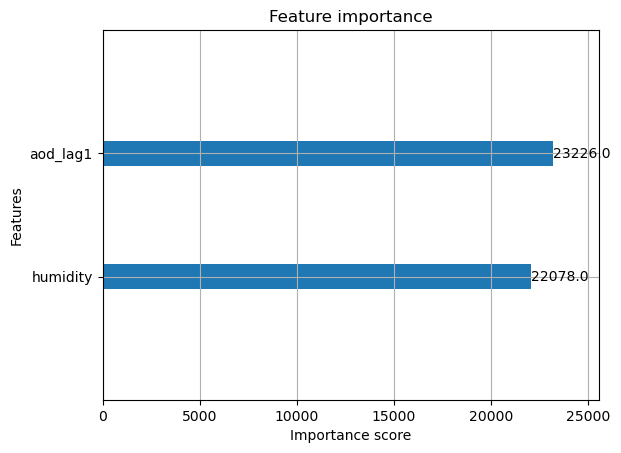

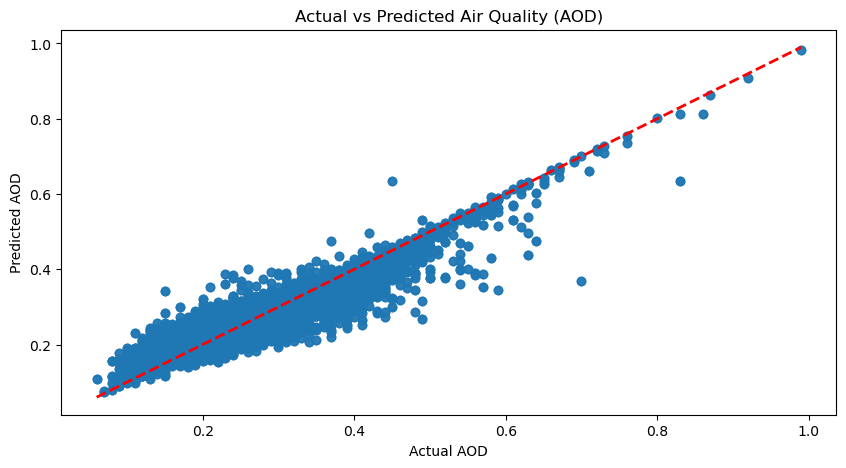

In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Tanza_AOD-Humidity-14-24daily.csv')

# --- THESIS TIP: Handle missing values ---
# Air quality sensors often have gaps. This removes empty rows.
df = df.dropna(subset=['aod', 'humidity'])

# 2. Preprocess Dates
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# 3. Define Features and Target
X = df[['humidity', 'year', 'month', 'day', 'dayofweek']]
y = df['aod']

# 3. Feature Engineering
# Create a lag feature (yesterday's AOD)
df['aod_lag1'] = df['aod'].shift(1)
df = df.dropna().copy() # Remove the first row which now has a NaN lag

# Define Features - explicitly use categorical types for time
X = df[['humidity', 'month', 'dayofweek', 'year', 'aod_lag1']].copy()
X['month'] = X['month'].astype('category')
X['dayofweek'] = X['dayofweek'].astype('category')

y = df['aod']

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # False is better for time-series

# 5. Model with Categorical Support
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist", # Required for categorical data
    enable_categorical=True, 
    early_stopping_rounds=50
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 6. Predictions and Evaluation
# --- THIS WAS THE MISSING LINE ---
predictions = model.predict(X_test) 

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# 7. Feature Importance
xgb.plot_importance(model)
plt.show()

# 8. Visualizing Actual vs Predicted (Optional but good for Thesis)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual AOD')
plt.ylabel('Predicted AOD')
plt.title('Actual vs Predicted Air Quality (AOD)')
plt.show()

In [4]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Calculate Metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# 2. Print the Report
print("--- Model Performance Report ---")
print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")

--- Model Performance Report ---
R2 Score (Accuracy): 0.8464
RMSE (Root Mean Squared Error): 0.0421
MAE (Mean Absolute Error): 0.0307
